# E-Commerce-Campaign-Analysis

## 1. Business Problem

An e-commerce company ran two promotional campaigns, a **Control Campaign** and a **Test Campaign**, to improve customer purchasing behavior. The company wants to determine whether the Test Campaign generated better sales conversion than the Control Campaign.

Simply observing a difference in purchases is not sufficient because differences may occur due to natural variation. Therefore, statistical hypothesis testing will be used to determine whether the observed difference in conversion performance is statistically significant.

### Business Question

**Did the Test Campaign significantly improve customer conversion compared with the Control Campaign?**

## 2. Project Objective

The main objectives of this project are:

* Compare the performance of the Control and Test Campaigns.
* Analyze customer conversion and purchasing behavior.
* Calculate and compare the conversion rates of both campaigns.
* Perform statistical hypothesis testing to determine whether the difference is significant.
* Identify which campaign performed better.
* Provide a data-driven recommendation on whether the Test Campaign should be adopted.


## 3. Dataset Description

This dataset contains user-level data from an **A/B testing experiment** designed to evaluate whether a new landing page improves user conversion.

The experiment consists of two groups:

* **Control Group:** Users shown the existing `old_page`.
* **Treatment Group:** Users shown the new `new_page`.

The dataset contains **294,478 rows and 5 columns**.

### Variables

| Variable       | Description                          |
| -------------- | ------------------------------------ |
| `user_id`      | Unique identifier for each user      |
| `timestamp`    | Date and time of user interaction    |
| `group`        | Control or treatment group           |
| `landing_page` | Old or new landing page              |
| `converted`    | 1 if the user converted, 0 otherwise |

The main variable of interest is **`converted`**. We will compare the conversion rates of the control and treatment groups and use statistical hypothesis testing to determine whether the observed difference is statistically significant.


## 4. Data Cleaning & Preparation

Before performing the analysis, the dataset will be inspected for
missing values, duplicate records, incorrect data types, invalid
experiment assignments, and other data quality issues.

In [4]:
import pandas as pd
df = pd.read_csv("ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [5]:
print("Dataset Shape:",df.shape)
df.info()

Dataset Shape: (294478, 5)
<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [6]:
duplicate_users = df["user_id"].duplicated().sum()
print("Duplicate user IDs:",duplicate_users)

Duplicate user IDs: 3894


In [7]:
duplicate_rows = df[df["user_id"].duplicated(keep = False)]
duplicate_rows.sort_values("user_id").head(20)

,user_id,timestamp,group,landing_page,converted
213114,630052,2017-01-07 12:25:54.089486,treatment,old_page,1
230259,630052,2017-01-17 01:16:05.208766,treatment,new_page,0
251762,630126,2017-01-19 17:16:00.280440,treatment,new_page,0
22513,630126,2017-01-14 13:35:54.778695,treatment,old_page,0
11792,630137,2017-01-22 14:59:22.051308,control,new_page,0
183371,630137,2017-01-20 02:08:49.893878,control,old_page,0
255753,630320,2017-01-12 05:27:37.181803,treatment,old_page,0
207211,630320,2017-01-07 18:02:43.626318,control,old_page,0
110634,630471,2017-01-23 01:42:51.501851,control,old_page,0
96929,630471,2017-01-07 02:14:17.405726,control,new_page,0


In [8]:
unique_duplicate_users = df.loc[df["user_id"].duplicated(keep=False),"user_id"].nunique()
print("Users appearing more than once:", unique_duplicate_users)

Users appearing more than once: 3894


In [9]:
exact_duplicates = df.duplicated().sum()
print("Exact duplicate rows:",exact_duplicates)

Exact duplicate rows: 0


In [10]:
pd.crosstab(df["group"],df["landing_page"])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [11]:
df_clean = df[
    ((df["group"] == "control") & (df["landing_page"] == "old_page")) | 
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page"))
    ].copy()
print("Original dataset:", df.shape)
print("Cleaned dataset:", df_clean.shape)

Original dataset: (294478, 5)
Cleaned dataset: (290585, 5)


In [12]:
duplicate_users_clean = df_clean["user_id"].duplicated().sum()

print("Duplicate user records after cleaning:", duplicate_users_clean)

Duplicate user records after cleaning: 1


In [13]:
remaining_duplicate = df_clean[
    df_clean["user_id"].duplicated(keep=False)
]

remaining_duplicate

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [20]:
df_clean = df_clean.drop_duplicates(
    subset="user_id",
    keep="first"
).copy()

print("Final cleaned dataset:", df_clean.shape)
print("Remaining duplicate users:", df_clean["user_id"].duplicated().sum())

Final cleaned dataset: (290584, 5)
Remaining duplicate users: 0


In [14]:
print("Missing values:")
print(df_clean.isnull().sum())

print("\nUnique groups:")
print(df_clean["group"].unique())

print("\nUnique landing pages:")
print(df_clean["landing_page"].unique())

print("\nUnique conversion values:")
print(df_clean["converted"].unique())

Missing values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

Unique groups:
<StringArray>
['control', 'treatment']
Length: 2, dtype: str

Unique landing pages:
<StringArray>
['old_page', 'new_page']
Length: 2, dtype: str

Unique conversion values:
[0 1]


In [15]:
# Convert timestamp to datetime format
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

# Verify the data type
print(df_clean["timestamp"].dtype)

datetime64[us]


## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) will be performed to understand the
distribution of users across the Control and Treatment groups and to
compare their conversion performance.

In [16]:
# Count the number of users in each group
group_counts = df_clean["group"].value_counts()

group_counts

group
treatment    145311
control      145274
Name: count, dtype: int64

In [18]:
# Count converted and non-converted users in each group
conversion_counts = pd.crosstab(df_clean["group"], df_clean["converted"])

conversion_counts

converted,0,1
group,,
control,127785,17489
treatment,128047,17264


In [19]:
# Calculate conversion rate for each group
conversion_rate = df_clean.groupby("group")["converted"].mean()

conversion_rate

group
control      0.120386
treatment    0.118807
Name: converted, dtype: float64

In [20]:
# Display conversion rates as percentages
conversion_rate_percent = conversion_rate * 100

conversion_rate_percent

group
control      12.038630
treatment    11.880725
Name: converted, dtype: float64

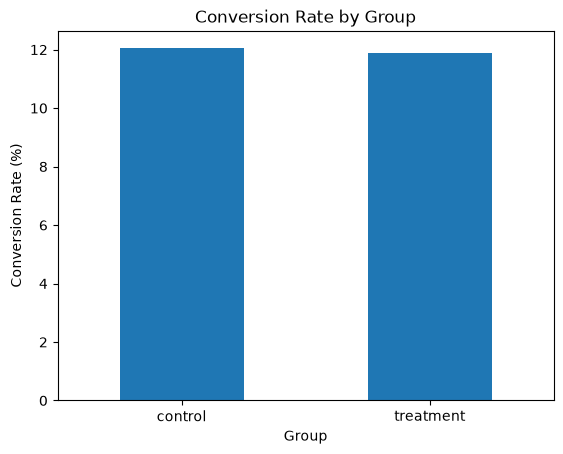

In [21]:
import matplotlib.pyplot as plt

# Plot conversion rate for each group
conversion_rate_percent.plot(kind="bar")

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Conversion Rate Comparison

The Control group has a conversion rate of approximately 12.04%, while the Treatment group has a conversion rate of approximately 11.88%.

The Treatment group therefore shows a slightly lower conversion rate than the Control group. However, the difference is small, and statistical testing is required to determine whether this difference is statistically significant.

In [22]:
# Calculate the difference in conversion rates
conversion_difference = (
    conversion_rate["treatment"] - conversion_rate["control"]
)

conversion_difference

np.float64(-0.0015790565976871451)

In [23]:
# Total users in each group
n_control = (df_clean["group"] == "control").sum()
n_treatment = (df_clean["group"] == "treatment").sum()

# Number of converted users in each group
x_control = ((df_clean["group"] == "control") &
             (df_clean["converted"] == 1)).sum()

x_treatment = ((df_clean["group"] == "treatment") &
               (df_clean["converted"] == 1)).sum()

print("Control users:", n_control)
print("Treatment users:", n_treatment)
print("Control conversions:", x_control)
print("Treatment conversions:", x_treatment)

Control users: 145274
Treatment users: 145311
Control conversions: 17489
Treatment conversions: 17264


In [24]:
# Calculate the pooled conversion rate
pooled_rate = (x_control + x_treatment) / (n_control + n_treatment)

pooled_rate

np.float64(0.11959667567149027)

In [26]:
# Calculate the standard error of the difference
import numpy as np
standard_error = np.sqrt(
    pooled_rate * (1 - pooled_rate) *
    (1 / n_treatment + 1 / n_control)
)

standard_error

np.float64(0.0012039093683579819)

In [27]:
# Calculate the z-statistic
z_stat = conversion_difference / standard_error

z_stat

np.float64(-1.3116075339133115)

In [28]:
from scipy.stats import norm

p_value = 2 * (1 - norm.cdf(abs(z_stat)))

p_value

np.float64(0.18965258971881793)

In [29]:
# Calculate conversion lift
conversion_lift = (
    (conversion_rate["treatment"] - conversion_rate["control"])
    / conversion_rate["control"]
) * 100

conversion_lift

np.float64(-1.31165800315857)

### A/B Test Summary

The Control group had a conversion rate of approximately 12.04%, while the Treatment group had a conversion rate of approximately 11.88%.

The Treatment group showed an observed relative conversion lift of approximately -1.31% compared with the Control group.

A two-proportion z-test produced a z-statistic of approximately -1.31 and a p-value of 0.18965. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis.

Therefore, there is insufficient statistical evidence to conclude that the Treatment campaign produced a different conversion rate from the Control group.

## 7. Results & Interpretation

The A/B test results were analyzed to compare the conversion performance of the Control and Treatment groups and determine whether the new landing page produced a statistically significant change in conversion.

In [30]:
# Create a summary of the A/B test results
results_summary = pd.DataFrame({
    "Metric": [
        "Control Conversion Rate",
        "Treatment Conversion Rate",
        "Conversion Difference",
        "Relative Conversion Lift",
        "Z-statistic",
        "P-value",
        "Significance Level"
    ],
    "Value": [
        f"{conversion_rate_percent['control']:.2f}%",
        f"{conversion_rate_percent['treatment']:.2f}%",
        f"{conversion_difference * 100:.3f} percentage points",
        f"{conversion_lift:.2f}%",
        f"{z_stat:.3f}",
        f"{p_value:.5f}",
        "0.05"
    ]
})

results_summary

,Metric,Value
0,Control Conversion Rate,12.04%
1,Treatment Conversion Rate,11.88%
2,Conversion Difference,-0.158 percentage points
3,Relative Conversion Lift,-1.31%
4,Z-statistic,-1.312
5,P-value,0.18965
6,Significance Level,0.05


### Conversion Rate Results

The Control group achieved a conversion rate of approximately 12.04%, while the Treatment group achieved a conversion rate of approximately 11.88%.

The Treatment group therefore had a conversion rate that was 0.158 percentage points lower than the Control group. In relative terms, this represents a 1.31% decrease in conversion compared with the Control group.

Although the observed conversion rate was slightly lower for the Treatment group, this difference alone does not establish that the new landing page performed worse.

### Statistical Significance

A two-proportion z-test was performed to determine whether the observed difference in conversion rates was statistically significant.

The test produced a z-statistic of approximately -1.312 and a p-value of 0.18965. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis.

Therefore, there is insufficient statistical evidence to conclude that the Treatment and Control groups have different conversion rates.

### Business Interpretation

The new landing page did not demonstrate a statistically significant improvement in conversion rate compared with the existing landing page.

Although the Treatment group showed a 1.31% relative decrease in conversion, the p-value of 0.18965 indicates that the observed difference is not statistically significant at the 5% significance level.

Therefore, based on this experiment, there is insufficient evidence to recommend replacing the existing landing page with the new version solely on the basis of conversion performance.

## 8. Business Recommendations

Based on the A/B test results, the new landing page should not be adopted as a replacement for the existing landing page based solely on conversion performance.

The Treatment group achieved a conversion rate of 11.88%, compared with 12.04% for the Control group, representing a 1.31% relative decrease. However, the difference was not statistically significant (p = 0.18965).

Therefore, the existing landing page should be retained as the current version while the new landing page is further evaluated or improved.

A future experiment could test a revised version of the landing page with additional improvements and a clearly defined target metric. Additional experiments may help determine whether specific design or content changes can produce a meaningful improvement in conversion.

## 9. Conclusion

This project evaluated the effectiveness of a new landing page using an A/B testing approach. After cleaning and analyzing the data, the Control group achieved a conversion rate of 12.04%, while the Treatment group achieved 11.88%, resulting in a relative decrease of 1.31% for the Treatment group.

A two-proportion z-test produced a p-value of 0.18965, which is greater than the 0.05 significance level. Therefore, the null hypothesis was not rejected, and there was insufficient statistical evidence to conclude that the new landing page produced a different conversion rate from the existing version.

Based on these findings, the existing landing page should be retained rather than replaced solely on the basis of conversion performance. Further experimentation with improved landing page designs and clearly defined objectives could be conducted to identify opportunities for increasing conversion.